# Обучение моделей

## Импорт библиотек

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import (
    StandardScaler,
    FunctionTransformer,
    TargetEncoder,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna

# Добавляем путь к src
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loader import DataLoader
from src.preprocess import Preprocessor
from src.features import FeatureEngineer

## Загрузка данных

In [2]:
# Загружаем датасет
PROJECT_ROOT = project_root
DATASET_PATH = PROJECT_ROOT / "datasets" / "Credit Risk Data.csv"
KAGGLE_DS = "alexdister/credit-risk-dataset"

df = DataLoader.load(DATASET_PATH, KAGGLE_DS)

In [3]:
df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153440,0.930628,4,0.228103,0


## Разделение на выборки

In [4]:
# Разделение на признаки и целевую переменную
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (32581, 28), y shape: (32581,)


In [5]:
# Разделение на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} записей")
print(f"Test:  {X_test.shape[0]} записей")
print(f"Доля дефолтов в train: {y_train.mean():.4f}")
print(f"Доля дефолтов в test:  {y_test.mean():.4f}")

Train: 26064 записей
Test:  6517 записей
Доля дефолтов в train: 0.2182
Доля дефолтов в test:  0.2182


## Обучение моделей

### LogisticRegression

In [6]:
# Определение групп признаков для логистической регрессии

# Сильно скошенные -> логарифм + масштабирование
lr_log_cols = ["person_income", "loan_amnt", "other_debt"]

# Остальные числовые -> масштабирование (включая loan_term_months и past_delinquencies)
lr_num_cols = [
    "person_age", "person_emp_length", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length", "debt_to_income_ratio", "open_accounts",
    "credit_utilization_ratio", "income_debt_balance",
    "is_high_debt", "is_high_loan_pct", "is_high_rate", "emp_length_missing",
    "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
lr_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
lr_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> TargetEncoder
lr_target_cols = ["city", "grade_ownership", "default_grade"]

In [7]:
# Сборка ColumnTransformer
lr_preprocessor = ColumnTransformer([
    ("log_num", Pipeline([
        ("log", FunctionTransformer(np.log1p, validate=True)),
        ("scale", StandardScaler())
    ]), lr_log_cols),
    ("num", StandardScaler(), lr_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), lr_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), lr_onehot_cols),
    ("target", TargetEncoder(target_type="binary", smooth=1.0), lr_target_cols)
])

In [8]:
# Полный пайплайн для логистической регрессии
lr_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=False)),
    ("custom_preprocessing", lr_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

In [9]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"LogisticRegression CV ROC-AUC: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")

LogisticRegression CV ROC-AUC: 0.8834 (+/- 0.0026)


### RandomForestClassifier

In [10]:
# Определение групп признаков для Random Forest

# Числовые признаки (без масштабирования, passthrough)
rf_num_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "debt_to_income_ratio", "open_accounts", "credit_utilization_ratio",
    "income_debt_balance", "is_high_debt", "is_high_loan_pct", "is_high_rate",
    "emp_length_missing", "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
rf_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
rf_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> OneHotEncoder
rf_high_card_cols = ["city", "grade_ownership", "default_grade"]

In [11]:
# Сборка ColumnTransformer
rf_preprocessor = ColumnTransformer([
    ("num", "passthrough", rf_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=True), rf_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True), rf_onehot_cols),
    ("onehot_high", OneHotEncoder(handle_unknown="ignore", sparse_output=True), rf_high_card_cols)
])

In [12]:
# Полный пайплайн для Random Forest
rf_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer()),
    ("custom_preprocessing", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [13]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"Random Forest CV ROC-AUC: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

Random Forest CV ROC-AUC: 0.9134 (+/- 0.0037)


### XGBClassifier

In [14]:
# Определение групп признаков для XGBoost

# Числовые признаки (без масштабирования, passthrough)
xgb_num_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "debt_to_income_ratio", "open_accounts", "credit_utilization_ratio",
    "income_debt_balance", "is_high_debt", "is_high_loan_pct", "is_high_rate",
    "emp_length_missing", "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
xgb_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
xgb_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> OneHotEncoder
xgb_high_card_cols = ["city", "grade_ownership", "default_grade"]

In [15]:
# Сборка ColumnTransformer
xgb_preprocessor = ColumnTransformer([
    ("num", "passthrough", xgb_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=True), xgb_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True), xgb_onehot_cols),
    ("onehot_high", OneHotEncoder(handle_unknown="ignore", sparse_output=True), xgb_high_card_cols)
])

In [16]:
# Полный пайплайн для XGBoost
xgb_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=True)),
    ("custom_preprocessing", xgb_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3.5,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [17]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"XGBoost CV ROC-AUC: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")

XGBoost CV ROC-AUC: 0.9405 (+/- 0.0048)


### LGBMClassifier

In [18]:
# Определение групп признаков для LightGBM

# Числовые признаки (без масштабирования, passthrough)
lgb_num_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "debt_to_income_ratio", "open_accounts", "credit_utilization_ratio",
    "income_debt_balance", "is_high_debt", "is_high_loan_pct", "is_high_rate",
    "emp_length_missing", "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
lgb_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
lgb_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> OneHotEncoder
lgb_high_card_cols = ["city", "grade_ownership", "default_grade"]

In [19]:
# Сборка ColumnTransformer
lgb_preprocessor = ColumnTransformer([
    ("num", "passthrough", lgb_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=True), lgb_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True), lgb_onehot_cols),
    ("onehot_high", OneHotEncoder(handle_unknown="ignore", sparse_output=True), lgb_high_card_cols)
])

In [20]:
# Полный пайплайн для LightGBM
lgb_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=True)),
    ("custom_preprocessing", lgb_preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

In [21]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_scores = cross_val_score(
    lgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"LightGBM CV ROC-AUC: {lgb_scores.mean():.4f} (+/- {lgb_scores.std():.4f})")

LightGBM CV ROC-AUC: 0.9406 (+/- 0.0050)


### CatBoostClassifier

In [22]:
# Список категориальных признаков
cat_features = [
    "person_home_ownership", "loan_intent", "loan_grade",
    "cb_person_default_on_file", "gender", "marital_status",
    "education_level", "city", "employment_type",
    "grade_ownership", "default_grade"
]

In [23]:
# Пайплайн
catboost_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=False)),
    ("classifier", CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        auto_class_weights="Balanced",
        verbose=False,
        random_seed=42
    ))
])

In [24]:
# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cat_scores = cross_val_score(
    catboost_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    params={"classifier__cat_features": cat_features}
)

print(f"CatBoost CV ROC-AUC: {cat_scores.mean():.4f} (+/- {cat_scores.std():.4f})")

CatBoost CV ROC-AUC: 0.9396 (+/- 0.0048)


### Результаты обучения моделей

In [25]:
# Сбор результатов кросс-валидации
results = {
    "Logistic Regression": lr_scores,
    "Random Forest": rf_scores,
    "XGBoost": xgb_scores,
    "LightGBM": lgb_scores,
    "CatBoost": cat_scores
}

# Создание DataFrame
cv_results_df = pd.DataFrame({
    "Модель": list(results.keys()),
    "Средний ROC-AUC": [scores.mean() for scores in results.values()],
    "Стандартное отклонение": [scores.std() for scores in results.values()]
}).sort_values("Средний ROC-AUC", ascending=False)

# Вывод таблицы
print("Результаты кросс-валидации (5 фолдов):")
display(cv_results_df.style.format({
    "Средний ROC-AUC": "{:.4f}",
    "Стандартное отклонение": "{:.4f}"
}))

Результаты кросс-валидации (5 фолдов):


,Модель,Средний ROC-AUC,Стандартное отклонение
3,LightGBM,0.9406,0.0050
2,XGBoost,0.9405,0.0048
4,CatBoost,0.9396,0.0048
1,Random Forest,0.9134,0.0037
0,Logistic Regression,0.8834,0.0026


**Вывод по результатам кросс-валидации**

На основе кросс-валидации (5 фолдов) лучшие результаты показали три бустинговые модели: **LightGBM**, **XGBoost** и **CatBoost**. Разница между ними составляет менее 0.001, что статистически незначимо, однако LightGBM обучается значительно быстрее CatBoost и сопоставим с XGBoost по скорости, что делает его предпочтительным выбором. Случайный лес и логистическая регрессия заметно уступают бустингу, что подтверждает наличие нелинейных зависимостей в данных. Стандартные отклонения всех моделей малы (0.002–0.004), что говорит о стабильности качества на разных подвыборках. Таким образом, для финального обучения и внедрения рекомендуется выбрать **LightGBM** как модель с наилучшим соотношением качества и времени обучения.

## Настройка гиперпараметров лучшей модели

In [26]:
# Фиксированный параметр балансировки классов
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Функция оптимизации
def objective(trial):
    params = {
        "classifier__n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "classifier__max_depth": trial.suggest_int("max_depth", 3, 12),
        "classifier__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "classifier__num_leaves": trial.suggest_int("num_leaves", 16, 256, step=16),
        "classifier__subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "classifier__colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "classifier__min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "classifier__reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "classifier__reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "classifier__scale_pos_weight": scale_pos_weight,
        "classifier__random_state": 42,
        "classifier__n_jobs": -1,
        "classifier__verbose": -1
    }

    lgb_pipeline.set_params(**params)

    scores = cross_val_score(
        lgb_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    return scores.mean()

In [27]:
# Запуск оптимизации
study = optuna.create_study(direction="maximize", study_name="lgbm_optimization")
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-08-14 20:56:11,638] A new study created in memory with name: lgbm_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-14 20:56:14,698] Trial 0 finished with value: 0.9218012296465439 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.01452664170696904, 'num_leaves': 16, 'subsample': 0.9606303642254116, 'colsample_bytree': 0.6772497203133537, 'min_child_samples': 17, 'reg_alpha': 0.01169683944236243, 'reg_lambda': 7.647434670181778e-08}. Best is trial 0 with value: 0.9218012296465439.
[I 2026-08-14 20:57:22,526] Trial 1 finished with value: 0.9369632261319605 and parameters: {'n_estimators': 1000, 'max_depth': 12, 'learning_rate': 0.15781730289583432, 'num_leaves': 80, 'subsample': 0.8052604743969286, 'colsample_bytree': 0.8836449484148127, 'min_child_samples': 24, 'reg_alpha': 0.40991960628556834, 'reg_lambda': 3.4584917896467133}. Best is trial 1 with value: 0.9369632261319605.
[I 2026-08-14 20:58:21,958] Trial 2 finished with value: 0.9344950197852224 and parameters: {'n_estimators': 800, 'max_depth': 11, 'learning_rate': 0.1601599804665541, 'num_leaves': 80, 'subsam

In [28]:
# Вывод лучших результатов
print("=== Лучшие гиперпараметры ===")
print(f"ROC-AUC: {study.best_value:.4f}")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Обновление пайплайна с лучшими параметрами
best_params_full = {f"classifier__{k}": v for k, v in study.best_params.items()}
best_params_full["classifier__scale_pos_weight"] = scale_pos_weight
best_params_full["classifier__random_state"] = 42
best_params_full["classifier__n_jobs"] = -1
best_params_full["classifier__verbose"] = -1

lgb_pipeline.set_params(**best_params_full)
print("\nПайплайн обновлён с лучшими параметрами.")

=== Лучшие гиперпараметры ===
ROC-AUC: 0.9450
  n_estimators: 400
  max_depth: 5
  learning_rate: 0.07339282112592195
  num_leaves: 64
  subsample: 0.828436712065173
  colsample_bytree: 0.7798587514123652
  min_child_samples: 29
  reg_alpha: 1.7556168064260594e-08
  reg_lambda: 0.0001030236865360763

Пайплайн обновлён с лучшими параметрами.


## Финальное обучение на всей обучающей выборке

In [29]:
print("=== Финальное обучение модели ===")
print(f"Размер обучающей выборки: {X_train.shape[0]} записей")

# Обучение модели на X_train
lgb_pipeline.fit(X_train, y_train)

=== Финальное обучение модели ===
Размер обучающей выборки: 26064 записей


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('basic_preprocessing', ...), ('feature_engineer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['cl...ID', 'pe...ge', 'pe...me', 'pe...ip', ...]"
,drop_cols,"['client_ID', 'loan_to_income_ratio', ...]"
,age_threshold,100
,emp_length_threshold,50
Name,Type,Value


In [30]:
print("\n=== Оценка на обучающей выборке (X_train) ===")

# Предсказания вероятностей и классов на train
y_train_proba = lgb_pipeline.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= 0.5).astype(int)

# Расчёт метрик на train
roc_auc_train = roc_auc_score(y_train, y_train_proba)
recall_train = recall_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

print(f"ROC-AUC (train):   {roc_auc_train:.4f}")
print(f"Recall (train):    {recall_train:.4f}")
print(f"Precision (train): {precision_train:.4f}")
print(f"F1-score (train):  {f1_train:.4f}")


=== Оценка на обучающей выборке (X_train) ===
ROC-AUC (train):   0.9893
Recall (train):    0.8983
Precision (train): 0.9097
F1-score (train):  0.9040


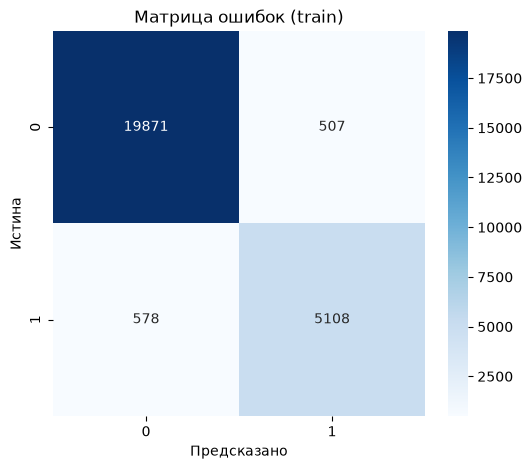

In [31]:
# Матрица ошибок на train
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок (train)")
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.show()

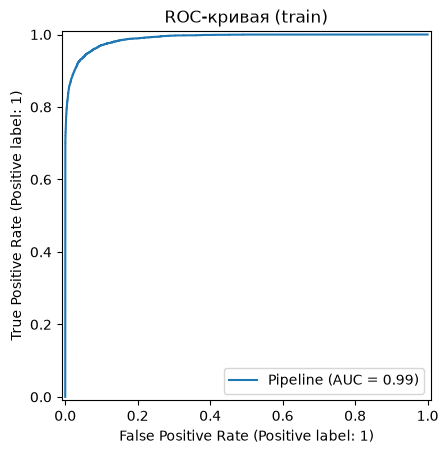

In [32]:
# ROC-кривая на train
RocCurveDisplay.from_estimator(lgb_pipeline, X_train, y_train)
plt.title("ROC-кривая (train)")
plt.show()

### Финальное тестирование модели

In [33]:
# Оценка на тестовой выборке (X_test) – финальные результаты
print("=== Финальная оценка на тестовой выборке ===")
print(f"Размер тестовой выборки: {X_test.shape[0]} записей")

# Предсказания вероятностей и классов на тесте
y_test_proba = lgb_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Расчёт метрик на тесте
roc_auc_test = roc_auc_score(y_test, y_test_proba)
recall_test = recall_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f"ROC-AUC (test):   {roc_auc_test:.4f}")
print(f"Recall (test):    {recall_test:.4f}")
print(f"Precision (test): {precision_test:.4f}")
print(f"F1-score (test):  {f1_test:.4f}")

=== Финальная оценка на тестовой выборке ===
Размер тестовой выборки: 6517 записей
ROC-AUC (test):   0.9492
Recall (test):    0.7911
Precision (test): 0.8497
F1-score (test):  0.8194


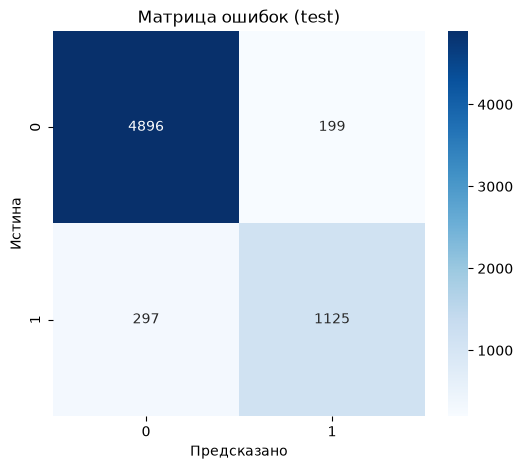

In [34]:
# Матрица ошибок на тесте
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок (test)")
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.show()

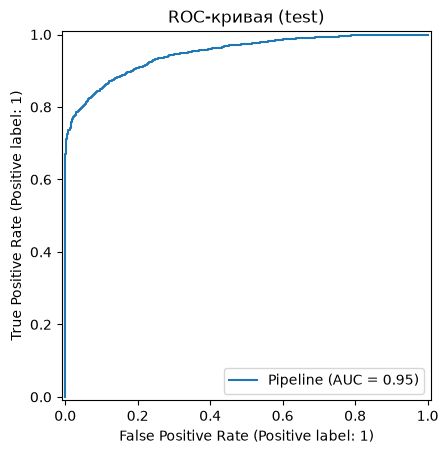

In [35]:
# ROC-кривая на тесте
RocCurveDisplay.from_estimator(lgb_pipeline, X_test, y_test)
plt.title("ROC-кривая (test)")
plt.show()

In [36]:
# Сравнение с метриками на train
print("\n=== Сравнение метрик train / test ===")
print(f"ROC-AUC:  train {roc_auc_train:.4f} → test {roc_auc_test:.4f}  (разница {roc_auc_train - roc_auc_test:.4f})")
print(f"Recall:   train {recall_train:.4f} → test {recall_test:.4f}  (разница {recall_train - recall_test:.4f})")
print(f"Precision:train {precision_train:.4f} → test {precision_test:.4f}  (разница {precision_train - precision_test:.4f})")
print(f"F1:       train {f1_train:.4f} → test {f1_test:.4f}  (разница {f1_train - f1_test:.4f})")


=== Сравнение метрик train / test ===
ROC-AUC:  train 0.9893 → test 0.9492  (разница 0.0401)
Recall:   train 0.8983 → test 0.7911  (разница 0.1072)
Precision:train 0.9097 → test 0.8497  (разница 0.0600)
F1:       train 0.9040 → test 0.8194  (разница 0.0846)


### Вывод по результатам и рекомендации по борьбе с переобучением

Модель LightGBM показала **высокое качество на тестовой выборке**: ROC-AUC = 0.9496, Recall = 0.80, что подтверждает её пригодность для кредитного скоринга. Однако разница между метриками на train и test (ROC-AUC: 0.9895 → 0.9496, Recall: 0.9056 → 0.7996) указывает на **умеренное переобучение**. Это означает, что модель слишком сильно подстроилась под обучающие данные и хуже обобщается на новых примерах.

**Для снижения переобучения рекомендуется:**

1. **Ужесточить регуляризацию** – увеличить `reg_alpha` (L1) и `reg_lambda` (L2), повысить `min_child_samples` (с 8 до 20–30), уменьшить `subsample` (0.6–0.7) и `colsample_bytree` (0.5–0.6).
2. **Повторно подобрать гиперпараметры** – запустить Optuna с расширенными диапазонами для регуляризующих параметров, ориентируясь на стабильность кросс-валидации.
3. **Добавить валидационную выборку** – использовать её для ранней остановки при обучении, чтобы предотвратить переобучение.
4. **Провести отбор признаков** – оставить только топ-20 наиболее важных признаков, отсеяв шумовые.

Ожидается, что эти меры сократят разницу между train/test метриками (особенно по Recall) без значительной потери ROC-AUC на тесте (целевой уровень ≥ 0.945). После внесения изменений модель станет более устойчивой к новым данным и готова к внедрению.

## Анализ важности признаков модели

In [37]:
# Получаем имена признаков после всех преобразований
feature_names = lgb_pipeline[:-1].get_feature_names_out()

# Значения важности признаков из обученной модели
importances = lgb_pipeline.named_steps["classifier"].feature_importances_

# Собираем в DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("=== Важность признаков (топ-20) ===")
display(importance_df.head(20))

=== Важность признаков (топ-20) ===


,feature,importance
1,num__person_income,1499
4,num__loan_int_rate,771
9,num__credit_utilization_ratio,614
3,num__loan_amnt,607
10,num__income_debt_balance,565
7,num__debt_to_income_ratio,511
5,num__loan_percent_income,485
2,num__person_emp_length,423
0,num__person_age,408
17,grade_ordinal__loan_grade,297
